# Kino Statistiken Österreich

Für unser Semesterprojekt analysieren wir diverse Statistiken über Kinobesuche innerhalb Österreichs.

## Daten Importieren

### Libraries

Zuerst importieren wir die Libraries die wir für unser Projekt brauchen:

In [131]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

### CSV Dateien

Dann importieren wir die CSV-Dateien, welche uns online zur Verfügung gestellt wurden:

In [120]:
# Quelle: https://www.statistik.at/statistiken/bevoelkerung-und-soziales/kultur/kinos-und-filme, via Statistik Austria (stand 2021, zuletzt heruntergeladen am 10.04.2024)
cinstructure = pd.read_csv('Struktur der Kinos (Anzahl der Säle, Sitzplatzkapazität, Bespielung) 2021 nach Bundesländern (Tabelle).csv')

# Quelle: https://www.statistik.at/statistiken/bevoelkerung-und-soziales/kultur/kinos-und-filme, via Statistik Austria (stand 2021, zuletzt heruntergeladen am 10.04.2024)
cinmarketshare = pd.read_csv('Marktanteile der erstaufgeführten Kinofilme 2021 nach Herkunftsländern (Tabelle).csv', sep=';')

# Quelle: https://www.wien.gv.at/statistik/kultur-sport/kultur/#daten, via Stadt Wien (stand 2021, zuletzt heruntergeladen am 10.04.2024)
# EDIT: im Jahr 2020 sind die Kinobesuche fehlerhaft (Referenz: https://www.wien.gv.at/statistik/pdf/jahrbuch.pdf, S.185), dementsprechende Änderungen wurden vorgenommen
cinfonds = pd.read_csv('tab_12.3.1_kunstundkultur_.csv', sep=';', skiprows=1, skipfooter=3, engine='python') 

print(cinmarketshare.columns)
print(cinfonds.columns)

Index(['Herkunftsland', 'Anzahl der Filme', 'Besuche in Tausend',
       'Besuche in Prozent'],
      dtype='object')
Index(['Jahr *', 'Kinosäle *', 'Sitzplatzkapazität *', 'Kinobesuche',
       'Nettoeinnahmen', 'Filmfonds Wien', 'Unnamed: 6'],
      dtype='object')


## Daten Visualisieren

Nun wollen wir die Daten grafisch darstellen.

### Verteilung von Kinoplätzen nach Bundesland



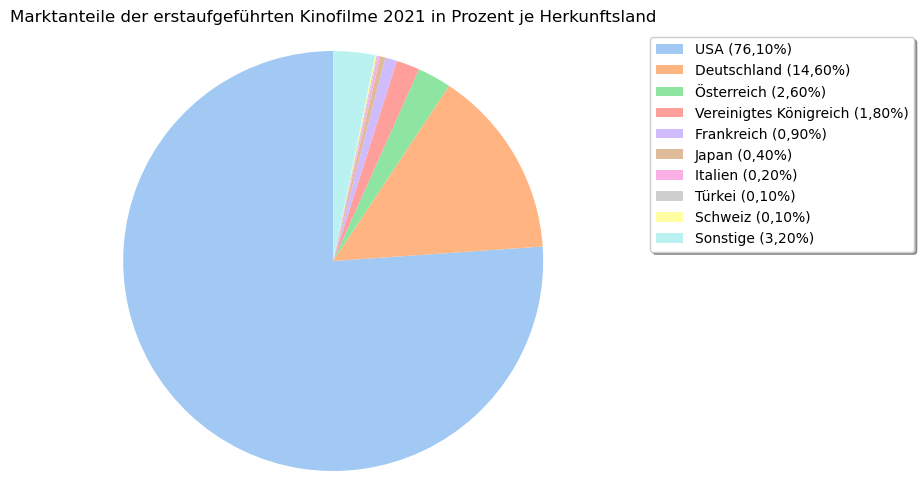

In [121]:
# Tabelle "Insgesamt" aus der Berechnung ausschließen
cinmarketshare_filtered = cinmarketshare[cinmarketshare["Herkunftsland"] != "Insgesamt"] 
# Farben festlegen
colors = sns.color_palette("pastel")

# Tortendiagramm erstellen
plt.figure(figsize=(8, 6))
patches, _ = plt.pie(cinmarketshare_filtered["Besuche in Prozent"].str.replace(',', '.').astype(float), colors=colors, startangle=90)
plt.title("Marktanteile der erstaufgeführten Kinofilme 2021 in Prozent je Herkunftsland") # Titel
plt.axis("equal")  # So bleibt das Diagramm rund

# Legende erstellen die Sowohl das Land als auch den Marktanteil formatiert anzeigt
legend_labels = [f"{country} ({percent:.2f}%)".replace('.', ',',) for country, percent in zip(cinmarketshare_filtered["Herkunftsland"], cinmarketshare_filtered["Besuche in Prozent"].str.replace(',', '.').astype(float))]

# Legende anzeigen
plt.legend(patches, legend_labels, loc="best", bbox_to_anchor=(1, 1), fancybox=True, shadow=True)

# Tortendiagramm zeigen
plt.show()


   Jahr Kinosäle Sitzplatzkapazität Kinobesuche      Nettoeinnahmen  \
2  1985      101              22018    5295,056  21894,726132424435   
3  1986       95              20173    5062,971  21619,078072425746   
4  1987      101              20453    4626,528   20636,97739148129   
5  1988       98              18912    4219,773   19739,24987100572   
6  1989       96              19002    4349,397   18340,95186878193   

  Filmfonds Wien Unnamed  
2            NaN     NaN  
3            NaN     NaN  
4            NaN     NaN  
5            NaN     NaN  
6            NaN     NaN  
Jahr                  object
Kinosäle              object
Sitzplatzkapazität    object
Kinobesuche           object
Nettoeinnahmen        object
Filmfonds Wien        object
Unnamed               object
dtype: object


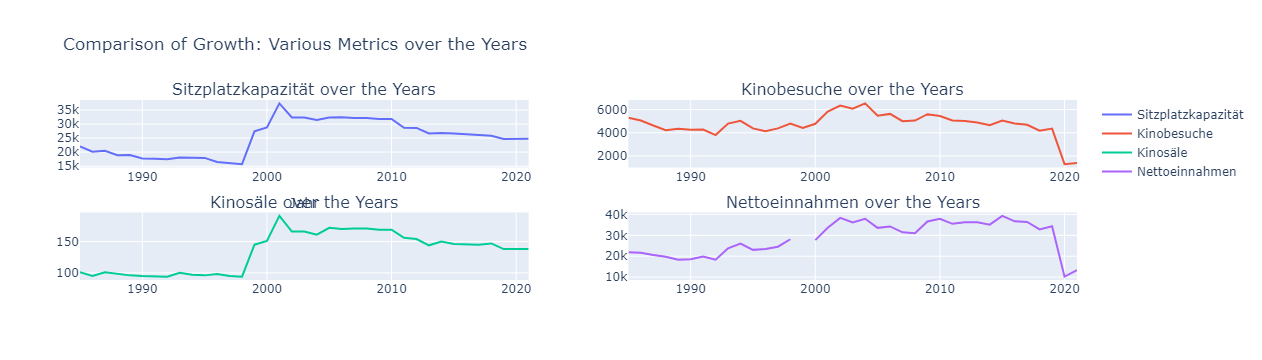

In [132]:
# Drop the third row from the DataFrame
cinfondsfiltered = cinfonds.drop(index=[0,1])
cinfondsfiltered.rename(columns={
    'Jahr *': 'Jahr',
    'Kinosäle *': 'Kinosäle',
    'Sitzplatzkapazität *': 'Sitzplatzkapazität',
    'Kinobesuche': 'Kinobesuche',
    'Nettoeinnahmen': 'Nettoeinnahmen',
    'Filmfonds Wien': 'Filmfonds Wien',
    'Unnamed: 6': 'Unnamed'
}, inplace=True)

# Display the first few rows of the data frame
print(cinfondsfiltered.head())

# Display the data types of the columns
print(cinfondsfiltered.dtypes)

def convert_and_round(x):
    # Check if x is a string
    if isinstance(x, str):
        # Replace comma with period if necessary
        x = x.replace(',', '.')
    try:
        # Convert to float and round to two decimal places
        return round(float(x), 2)
    except ValueError:
        # If conversion fails, return NaN (not a number)
        return float('nan')

# Convert necessary columns to numeric data types
cinfondsfiltered['Jahr'] = pd.to_numeric(cinfondsfiltered['Jahr'], errors='coerce')
cinfondsfiltered['Sitzplatzkapazität'] = pd.to_numeric(cinfondsfiltered['Sitzplatzkapazität'], errors='coerce')
cinfondsfiltered['Kinobesuche'] = cinfondsfiltered['Kinobesuche'].apply(convert_and_round)
cinfondsfiltered['Kinosäle'] = pd.to_numeric(cinfondsfiltered['Kinosäle'], errors='coerce')
cinfondsfiltered['Nettoeinnahmen'] = cinfondsfiltered['Nettoeinnahmen'].apply(convert_and_round)

# Create subplots with 2 rows and 2 columns
fig = make_subplots(rows=2, cols=2, subplot_titles=[
    "Sitzplatzkapazität over the Years",
    "Kinobesuche over the Years",
    "Kinosäle over the Years",
    "Nettoeinnahmen over the Years"
])

# Add line graph for Sitzplatzkapazität
fig.add_trace(
    go.Scatter(x=cinfondsfiltered['Jahr'], y=cinfondsfiltered['Sitzplatzkapazität'], mode='lines', name='Sitzplatzkapazität'),
    row=1, col=1
)

# Add line graph for Kinobesuche
fig.add_trace(
    go.Scatter(x=cinfondsfiltered['Jahr'], y=cinfondsfiltered['Kinobesuche'], mode='lines', name='Kinobesuche'),
    row=1, col=2
)

# Add line graph for Kinosäle
fig.add_trace(
    go.Scatter(x=cinfondsfiltered['Jahr'], y=cinfondsfiltered['Kinosäle'], mode='lines', name='Kinosäle'),
    row=2, col=1
)

# Add line graph for Nettoeinnahmen
fig.add_trace(
    go.Scatter(x=cinfondsfiltered['Jahr'], y=cinfondsfiltered['Nettoeinnahmen'], mode='lines', name='Nettoeinnahmen'),
    row=2, col=2
)

# Update layout and add titles
fig.update_layout(
    title_text="Comparison of Growth: Various Metrics over the Years",
    xaxis_title="Jahr"
)

# Show the plot
fig.show()

# Hilfreiche Quellen

Statista Österreich bietet ebenso einige gute Diagramme zur übersichtlichen Darstellung von Kinobesuchern:
https://de.statista.com/statistik/daten/studie/299996/umfrage/kinobesuche-in-oesterreich/

Die WKO liefert einen Überblick über die gesamten Kinobesucher pro Monat von ganz Österreich, seit 2006. Daten sind leider nicht als CSV vorhanden:
https://www.wko.at/oe/tourismus-freizeitwirtschaft/kino-kultur-vergnuegungsbetriebe/statistik

Film Austria ist eine Vereinigung Kreativer Filmproduzenten und hat als Ziel, die österreichische Filmkultur zu zelebrieren. Die Webseite bietet laufend Besucherdaten über in österreich-produzierte Filme:
https://www.filmaustria.com/kino-charts

Die Kulturstatistik 2021 von Statistik Austria bietet genaue Einblicke in die kulturelle Entwicklungen von Filmbasierenden Medien:
https://www.statistik.at/fileadmin/user_upload/Kulturstatistik-2021_Web-barrierefrei.pdf

Die Kulturstatistiken der Stadt Wien bieten auch noch einen genaueren Einblick in Kinos und Filmfonds von Österreich:
https://www.wien.gv.at/statistik/kultur-sport/kultur/

# Ideen
Interaktiver Kinosaal, bei dem Anhand von Kinositzen die Kinoplätze/Kinobesucher pro Bundesland angezeigt werden.

Ein Pie Chart, dass die Marktanteile der erstaufgeführten Kinofilme (2021) nach Herkunftsländer aufzeigt.





# Notizen vom Feedback

